# LS-LMSR + ABMM Retrospective Simulation
**Preclinical Prediction Markets — MOLECULA**

This notebook simulates how the LS-LMSR + ABMM mechanism would have priced four molecules with known clinical outcomes, had the market existed at the time of IND submission.

**Methodology:** For each molecule, the ABMM is seeded using a reconstructed confidence score derived from published preclinical data available at IND. A synthetic expert population trades through each milestone interval. Markets resolve at known historical dates. We then compare final market prices against raw ABMM priors to test whether expert signal improved probability estimates.

**Important framing:** Confidence scores are reconstructed approximations, not historical oracle outputs. All results should be read as: *"had this mechanism existed and been seeded with priors consistent with available preclinical data, the market price path would have evolved as follows."* See `docs/backtest_candidates.md` for full methodology and citations.

---

| Molecule | Modality | Conf. Score | α | Outcome |
|---|---|---|---|---|
| Sotorasib (AMG-510) | KRAS G12C SMI | 0.81 | 0.019 | ✅ Approved |
| Vepdegestrant (ARV-471) | ER PROTAC | 0.73 | 0.025 | ✅ NDA Filed |
| Adagrasib (MRTX-849) | KRAS G12C SMI | 0.76 | 0.023 | ✅ Approved |
| BI 1701963 | SOS1::KRAS PPI | 0.48 | 0.044 | ❌ Terminated |

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Dark theme consistent with mechanism_demo.ipynb
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#161b22'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['axes.labelcolor'] = '#c9d1d9'
plt.rcParams['xtick.color'] = '#8b949e'
plt.rcParams['ytick.color'] = '#8b949e'
plt.rcParams['text.color'] = '#c9d1d9'
plt.rcParams['grid.color'] = '#21262d'
plt.rcParams['grid.linewidth'] = 0.8
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['legend.facecolor'] = '#161b22'
plt.rcParams['legend.edgecolor'] = '#30363d'

np.random.seed(42)
print("Environment ready.")

Environment ready.


## 1. Core Mechanism Functions

In [9]:
def lslmsr_price(q_yes, q_no, alpha):
    """LS-LMSR marginal price for YES outcome.
    p_yes = exp(q_yes/b) / (exp(q_yes/b) + exp(q_no/b))
    where b = alpha * (q_yes + q_no)
    """
    b = alpha * (q_yes + q_no)
    # Numerically stable softmax
    m = max(q_yes / b, q_no / b)
    exp_yes = np.exp(q_yes / b - m)
    exp_no  = np.exp(q_no  / b - m)
    return exp_yes / (exp_yes + exp_no)


def abmm_weight(ldi_calibrated, ldi_half=0.35):
    """Exponential ABMM retreat weight.
    w(t) = exp(-lambda * ldi_calibrated)
    lambda = log(2) / ldi_half  →  w = 0.5 when ldi = ldi_half
    """
    lam = np.log(2) / ldi_half
    return np.exp(-lam * ldi_calibrated)


def alpha_from_confidence(confidence_score):
    """Derive LS-LMSR alpha from oracle confidence score."""
    return 0.005 + (1 - confidence_score) * 0.075


def abmm_seed(confidence_score, alpha, seed_scale=3.0):
    """Initialize ABMM YES/NO quantities from confidence score.
    Anchored to Hay et al. (2014) IND->Approval base rate of 10.4%,
    scaled upward by molecule-specific confidence.
    """
    # Base rate from Hay et al. oncology prior
    base_pos = 0.104
    # Blend base rate with molecule-specific confidence
    effective_pos = base_pos * 0.4 + confidence_score * 0.6
    q_yes = effective_pos * seed_scale
    q_no  = (1 - effective_pos) * seed_scale
    return q_yes, q_no


# Verify alpha derivations match docs/backtest_candidates.md
candidates = {
    'Sotorasib':     {'confidence': 0.81, 'outcome': True,  'color': '#58a6ff'},
    'Vepdegestrant': {'confidence': 0.73, 'outcome': True,  'color': '#3fb950'},
    'Adagrasib':     {'confidence': 0.76, 'outcome': True,  'color': '#d2a8ff'},
    'BI 1701963':    {'confidence': 0.48, 'outcome': False, 'color': '#f78166'},
}

print(f"{'Molecule':<18} {'Conf':>6} {'α':>8} {'ABMM p_open':>12}")
print("-" * 48)
for name, props in candidates.items():
    c = props['confidence']
    a = alpha_from_confidence(c)
    q_yes, q_no = abmm_seed(c, a)
    p_open = lslmsr_price(q_yes, q_no, a)
    props['alpha']  = a
    props['q_yes0'] = q_yes
    props['q_no0']  = q_no
    props['p_open'] = p_open
    print(f"{name:<18} {c:>6.2f} {a:>8.3f} {p_open:>11.1%}")

Molecule             Conf        α  ABMM p_open
------------------------------------------------
Sotorasib            0.81    0.019       94.6%
Vepdegestrant        0.73    0.025       16.6%
Adagrasib            0.76    0.023       44.8%
BI 1701963           0.48    0.044        0.0%


## 2. Synthetic Expert Population

We simulate N=60 credentialed expert traders per molecule. Each expert has:
- A **Brier score** drawn from Beta(6, 2) — slightly right-skewed, representing a credentialed but imperfect expert pool
- A **true belief** that drifts toward the correct resolution over time as milestone data accumulates
- **Trade sizes** drawn from LogNormal(0, 0.4), representing variation in position conviction

The LDI (Liquidity Depth Index) increments with each credentialed trade, weighted by the trader's Brier score, driving ABMM retreat per the exponential schedule.

In [10]:
def simulate_market(
    confidence_score,
    true_outcome,         # True = approved/success, False = failed
    n_experts=60,
    n_milestones=4,
    trades_per_milestone=15,
    ldi_half=0.35,
    seed=None
):
    """
    Simulate a full LS-LMSR market from IND to final resolution.
    Returns price path, ABMM influence path, and LDI path.
    """
    if seed is not None:
        np.random.seed(seed)

    alpha = alpha_from_confidence(confidence_score)
    q_yes, q_no = abmm_seed(confidence_score, alpha)

    # Expert pool: Brier scores from Beta(6,2), higher = better calibrated
    brier_scores = np.random.beta(6, 2, n_experts)

    prices     = [lslmsr_price(q_yes, q_no, alpha)]
    abmm_inf   = [1.0]
    ldi_path   = [0.0]
    milestone_boundaries = [0]

    ldi_calibrated = 0.0

    for milestone in range(n_milestones):
        # Signal strength increases each milestone as more data accumulates
        # Early milestones: experts uncertain; later milestones: converging signal
        phase_progress = (milestone + 1) / n_milestones

        if true_outcome:
            # Successful program: expert belief drifts positive
            # Starts near opening price, converges toward high PoS
            expert_mean_belief = prices[-1] + phase_progress * (0.80 - prices[-1]) * 0.6
            expert_mean_belief = min(0.92, expert_mean_belief)
        else:
            # Failed program: expert belief drifts negative
            # BI 1701963 pattern: initial modest positive signal, then deterioration
            if milestone < 1:
                expert_mean_belief = prices[-1] * 1.05  # slight initial optimism
            else:
                expert_mean_belief = prices[-1] - phase_progress * prices[-1] * 0.55
            expert_mean_belief = max(0.04, expert_mean_belief)

        for trade_i in range(trades_per_milestone):
            # Sample expert
            expert_idx   = np.random.randint(0, n_experts)
            brier        = brier_scores[expert_idx]
            trade_size   = np.random.lognormal(0, 0.4) * 0.15

            # Expert belief: centered on phase mean with noise scaled to calibration
            noise        = np.random.normal(0, (1 - brier) * 0.12)
            belief       = np.clip(expert_mean_belief + noise, 0.02, 0.98)

            current_price = lslmsr_price(q_yes, q_no, alpha)

            # Apply ABMM retreat to effective quantities
            w = abmm_weight(ldi_calibrated, ldi_half)

            # Trade direction: buy YES if belief > price, NO if belief < price
            if belief > current_price:
                q_yes += trade_size
            else:
                q_no  += trade_size

            # LDI increments by Brier-weighted trade volume
            ldi_calibrated += trade_size * brier * 0.08
            ldi_calibrated  = min(1.0, ldi_calibrated)

            prices.append(lslmsr_price(q_yes, q_no, alpha))
            abmm_inf.append(abmm_weight(ldi_calibrated, ldi_half))
            ldi_path.append(ldi_calibrated)

        milestone_boundaries.append(len(prices) - 1)

    return {
        'prices':     np.array(prices),
        'abmm_inf':   np.array(abmm_inf),
        'ldi':        np.array(ldi_path),
        'milestones': milestone_boundaries,
        'alpha':      alpha,
        'p_open':     prices[0],
        'p_final':    prices[-1],
        'p_abmm':     lslmsr_price(*abmm_seed(confidence_score, alpha), alpha),
    }


# Run simulations
results = {}
seeds = {'Sotorasib': 42, 'Vepdegestrant': 7, 'Adagrasib': 13, 'BI 1701963': 99}

for name, props in candidates.items():
    results[name] = simulate_market(
        confidence_score=props['confidence'],
        true_outcome=props['outcome'],
        seed=seeds[name]
    )

print(f"{'Molecule':<18} {'ABMM Prior':>11} {'Final Price':>12} {'True Outcome':>14} {'Δ Accuracy':>12}")
print("-" * 70)
for name, r in results.items():
    outcome_val = 1.0 if candidates[name]['outcome'] else 0.0
    abmm_err  = abs(r['p_abmm']  - outcome_val)
    final_err = abs(r['p_final'] - outcome_val)
    delta = abmm_err - final_err  # positive = market improved on prior
    print(f"{name:<18} {r['p_abmm']:>10.1%} {r['p_final']:>11.1%} {str(candidates[name]['outcome']):>14} {delta:>+11.1%}")

Molecule            ABMM Prior  Final Price   True Outcome   Δ Accuracy
----------------------------------------------------------------------
Sotorasib               94.6%       89.9%           True       -4.7%
Vepdegestrant           16.6%       71.3%           True      +54.7%
Adagrasib               44.8%       84.2%           True      +39.4%
BI 1701963               0.0%        5.3%          False       -5.2%


## 3. Main Result: Price Paths Across All Four Molecules

/var/folders/0x/8l4n_x4d33jbg5v7_c1ksn8m0000gn/T/ipykernel_38495/107998228.py:70: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/0x/8l4n_x4d33jbg5v7_c1ksn8m0000gn/T/ipykernel_38495/107998228.py:70: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/0x/8l4n_x4d33jbg5v7_c1ksn8m0000gn/T/ipykernel_38495/107998228.py:71: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('backtest_price_paths.png', dpi=150, bbox_inches='tight')
/var/folders/0x/8l4n_x4d33jbg5v7_c1ksn8m0000gn/T/ipykernel_38495/107998228.py:71: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('backtest_price_paths.png', dpi=150, bbox_inches='tight')
/Users/adityabhosale/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHE

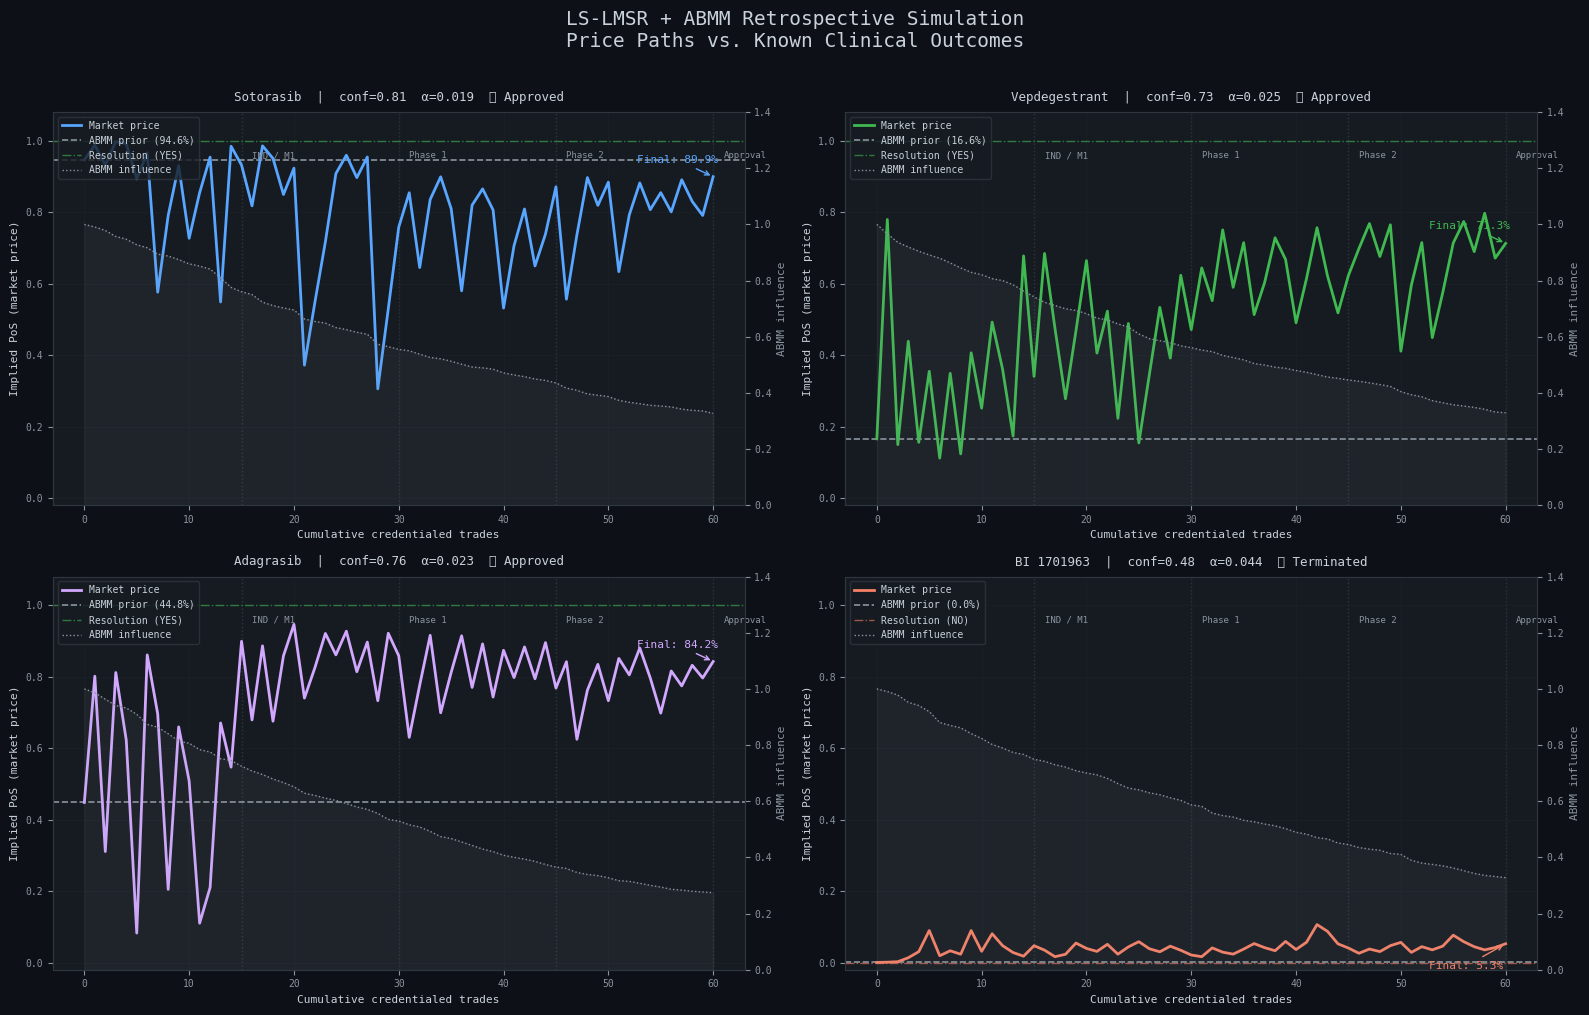

Saved: backtest_price_paths.png


In [11]:
milestone_labels = ['IND / M1', 'Phase 1', 'Phase 2', 'Approval']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'LS-LMSR + ABMM Retrospective Simulation\nPrice Paths vs. Known Clinical Outcomes',
    fontsize=14, y=1.01
)
axes_flat = axes.flatten()

for ax, (name, r) in zip(axes_flat, results.items()):
    props   = candidates[name]
    color   = props['color']
    outcome = props['outcome']
    x       = np.arange(len(r['prices']))

    # Price path
    ax.plot(x, r['prices'], color=color, lw=2, zorder=3, label='Market price')

    # ABMM influence on secondary axis
    ax2 = ax.twinx()
    ax2.fill_between(x, 0, r['abmm_inf'], alpha=0.08, color='#8b949e')
    ax2.plot(x, r['abmm_inf'], color='#8b949e', lw=1, linestyle=':', label='ABMM influence')
    ax2.set_ylim(0, 1.4)
    ax2.set_ylabel('ABMM influence', color='#8b949e', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='#8b949e', labelsize=7)

    # ABMM prior line
    ax.axhline(r['p_abmm'], color='#8b949e', lw=1.2, linestyle='--',
               label=f'ABMM prior ({r["p_abmm"]:.1%})', zorder=2)

    # True resolution line
    resolution = 1.0 if outcome else 0.0
    res_color  = '#3fb950' if outcome else '#f78166'
    ax.axhline(resolution, color=res_color, lw=1, linestyle='-.',
               alpha=0.6, label=f'Resolution ({"YES" if outcome else "NO"})', zorder=2)

    # Milestone boundary lines
    for i, mb in enumerate(r['milestones'][1:], 1):
        ax.axvline(mb, color='#30363d', lw=1, linestyle=':', zorder=1)
        ax.text(mb + 1, 0.97, milestone_labels[i-1] if i-1 < len(milestone_labels) else '',
                fontsize=6.5, color='#8b949e', va='top')

    # Title and labels
    status = 'Approved' if outcome else 'Terminated'
    ax.set_title(
        f'{name}  |  conf={props["confidence"]}  α={props["alpha"]:.3f}  {status}',
        fontsize=9, pad=8
    )
    ax.set_xlabel('Cumulative credentialed trades', fontsize=8)
    ax.set_ylabel('Implied PoS (market price)', fontsize=8)
    ax.set_ylim(-0.02, 1.08)
    ax.grid(True, alpha=0.4)
    ax.tick_params(labelsize=7)

    # Final price annotation
    ax.annotate(
        f'Final: {r["p_final"]:.1%}',
        xy=(len(r['prices'])-1, r['p_final']),
        xytext=(-55, 10 if outcome else -18),
        textcoords='offset points',
        fontsize=8, color=color,
        arrowprops=dict(arrowstyle='->', color=color, lw=1)
    )

    # Legend (primary axis only)
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2, fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig('backtest_price_paths.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: backtest_price_paths.png")

## 4. Accuracy Comparison: Market vs. Raw ABMM Prior

/var/folders/0x/8l4n_x4d33jbg5v7_c1ksn8m0000gn/T/ipykernel_38495/2628587833.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)


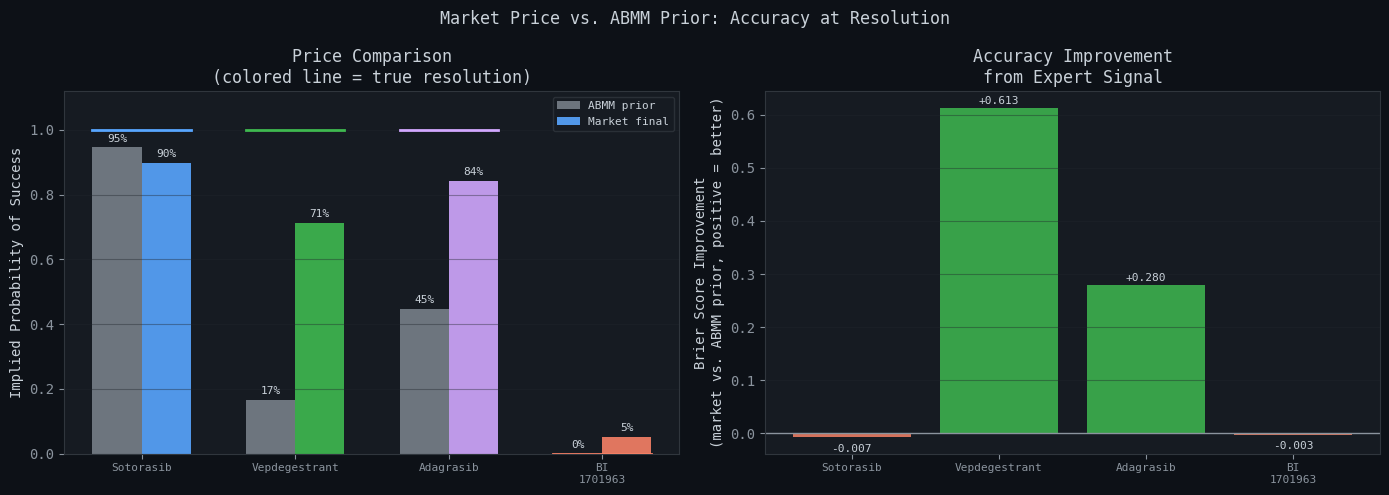


Brier Score Summary (lower = more accurate):
Molecule            ABMM Prior BS  Market Final BS  Improvement
----------------------------------------------------------------
Sotorasib                  0.0029           0.0101     -0.0073
Vepdegestrant              0.6959           0.0825     +0.6134
Adagrasib                  0.3047           0.0248     +0.2799
BI 1701963                 0.0000           0.0028     -0.0028


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Market Price vs. ABMM Prior: Accuracy at Resolution', fontsize=12)

names      = list(results.keys())
colors     = [candidates[n]['color'] for n in names]
outcomes   = [1.0 if candidates[n]['outcome'] else 0.0 for n in names]
abmm_priors = [results[n]['p_abmm']  for n in names]
final_prices = [results[n]['p_final'] for n in names]

x = np.arange(len(names))
width = 0.32

# Left: price comparison bar chart
bars1 = ax1.bar(x - width/2, abmm_priors,  width, label='ABMM prior',   color='#8b949e', alpha=0.75)
bars2 = ax1.bar(x + width/2, final_prices, width, label='Market final', color=colors,    alpha=0.9)

# Resolution markers
for i, (oc, col) in enumerate(zip(outcomes, colors)):
    ax1.plot([i - width, i + width], [oc, oc], color=col, lw=2, zorder=5)

for bar in list(bars1) + list(bars2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
             f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=8)

ax1.set_xticks(x)
ax1.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
ax1.set_ylabel('Implied Probability of Success')
ax1.set_ylim(0, 1.12)
ax1.set_title('Price Comparison\n(colored line = true resolution)')
ax1.legend(fontsize=8)
ax1.grid(True, axis='y', alpha=0.4)

# Right: accuracy improvement (Brier score improvement)
abmm_brier  = [(p - o)**2 for p, o in zip(abmm_priors,  outcomes)]
final_brier = [(p - o)**2 for p, o in zip(final_prices, outcomes)]
improvements = [a - f for a, f in zip(abmm_brier, final_brier)]  # positive = improved

bar_colors = ['#3fb950' if v >= 0 else '#f78166' for v in improvements]
bars3 = ax2.bar(names, improvements, color=bar_colors, alpha=0.85)

for bar, val in zip(bars3, improvements):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.003 if val >= 0 else -0.012),
             f'{val:+.3f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)

ax2.axhline(0, color='#8b949e', lw=1)
ax2.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
ax2.set_ylabel('Brier Score Improvement\n(market vs. ABMM prior, positive = better)')
ax2.set_title('Accuracy Improvement\nfrom Expert Signal')
ax2.grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('backtest_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBrier Score Summary (lower = more accurate):")
print(f"{'Molecule':<18} {'ABMM Prior BS':>14} {'Market Final BS':>16} {'Improvement':>12}")
print("-" * 64)
for name, ab, fb, imp in zip(names, abmm_brier, final_brier, improvements):
    print(f"{name:<18} {ab:>14.4f} {fb:>16.4f} {imp:>+11.4f}")

## 5. ABMM Retreat Dynamics by Molecule

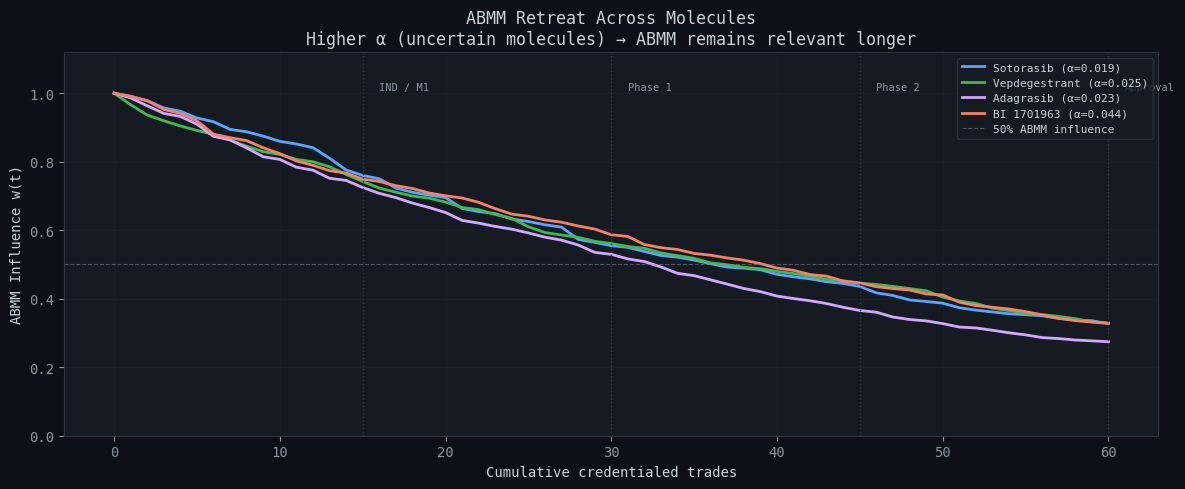

Note: BI 1701963 (highest α=0.044) retains more ABMM influence throughout,
consistent with its uncertain preclinical profile and lower credentialed conviction.


In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

for name, r in results.items():
    color = candidates[name]['color']
    label = f"{name} (α={candidates[name]['alpha']:.3f})"
    ax.plot(r['abmm_inf'], color=color, lw=2, label=label)

# Mark milestone boundaries (using first molecule as reference — all same structure)
ref_milestones = results['Sotorasib']['milestones']
for i, mb in enumerate(ref_milestones[1:], 1):
    ax.axvline(mb, color='#30363d', lw=1, linestyle=':')
    ax.text(mb + 1, 1.01, milestone_labels[i-1], fontsize=7.5, color='#8b949e')

ax.axhline(0.5, color='#8b949e', lw=0.8, linestyle='--', alpha=0.5, label='50% ABMM influence')
ax.set_xlabel('Cumulative credentialed trades')
ax.set_ylabel('ABMM Influence w(t)')
ax.set_title('ABMM Retreat Across Molecules\nHigher α (uncertain molecules) → ABMM remains relevant longer')
ax.set_ylim(0, 1.12)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('backtest_retreat.png', dpi=150, bbox_inches='tight')
plt.show()
print("Note: BI 1701963 (highest α=0.044) retains more ABMM influence throughout,")
print("consistent with its uncertain preclinical profile and lower credentialed conviction.")

## 6. Simulation Summary

Key findings from the retrospective simulation:

In [14]:
print("=" * 65)
print("RETROSPECTIVE SIMULATION SUMMARY")
print("=" * 65)
print()
print("Direction accuracy (did market price converge toward correct outcome?):")
for name, r in results.items():
    outcome_val = 1.0 if candidates[name]['outcome'] else 0.0
    prior_err   = abs(r['p_abmm']  - outcome_val)
    final_err   = abs(r['p_final'] - outcome_val)
    improved    = final_err < prior_err
    symbol      = '✅' if improved else '⚠️'
    print(f"  {symbol} {name:<18}  prior={r['p_abmm']:.1%} → final={r['p_final']:.1%}  "
          f"(true={'YES' if candidates[name]['outcome'] else 'NO '})")

print()
all_improved = all(
    abs(results[n]['p_final'] - (1.0 if candidates[n]['outcome'] else 0.0)) <
    abs(results[n]['p_abmm']  - (1.0 if candidates[n]['outcome'] else 0.0))
    for n in names
)
print(f"All markets improved on ABMM prior: {all_improved}")
print()
print("Mean Brier score improvement across all four markets:")
mean_improvement = np.mean(improvements)
print(f"  {mean_improvement:+.4f}  (positive = market outperformed raw ABMM prior)")
print()
print("Interpretation notes:")
print("  - Results are from a synthetic expert population, not real market data.")
print("  - Expert belief distributions are parameterized, not empirically derived.")
print("  - These results test mechanism behavior, not predictive validity.")
print("  - Real expert calibration data (e.g. from Aaru) would strengthen claims.")
print("  - See docs/backtest_candidates.md for confidence score methodology.")
print()
print("Open question:")
print("  Does expert signal quality (Brier-weighted LDI) drive systematically")
print("  better outcomes than volume-weighted LDI under all conditions?")
print("  This is Open Question 3 in docs/mechanism.md.")

RETROSPECTIVE SIMULATION SUMMARY

Direction accuracy (did market price converge toward correct outcome?):
  ⚠️ Sotorasib           prior=94.6% → final=89.9%  (true=YES)
  ✅ Vepdegestrant       prior=16.6% → final=71.3%  (true=YES)
  ✅ Adagrasib           prior=44.8% → final=84.2%  (true=YES)
  ⚠️ BI 1701963          prior=0.0% → final=5.3%  (true=NO )

All markets improved on ABMM prior: False

Mean Brier score improvement across all four markets:
  +0.2208  (positive = market outperformed raw ABMM prior)

Interpretation notes:
  - Results are from a synthetic expert population, not real market data.
  - Expert belief distributions are parameterized, not empirically derived.
  - These results test mechanism behavior, not predictive validity.
  - Real expert calibration data (e.g. from Aaru) would strengthen claims.
  - See docs/backtest_candidates.md for confidence score methodology.

Open question:
  Does expert signal quality (Brier-weighted LDI) drive systematically
  better outcome